In [ ]:
!pip install langchain langchain-huggingface langchain-community langgraph

In [ ]:
# from google.colab import userdata
# userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [3]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [4]:
from typing import Annotated

from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.messages import AIMessage, AnyMessage

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [ ]:
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen3-4B-Instruct-2507",
    task = "text-generation",
)
model = ChatHuggingFace(llm = llm)

## Method 1 (Invoke a Graph From a Node)

In [6]:
class SubState(TypedDict):
  input_text: str
  translated_text: str

In [7]:
def translateToHindi(state: SubState):
  prompt = f"Translate the following text to hindi, keep it natural and clear, do not add any extra content. Text: {state["input_text"]}".strip()
  translated_text = model.invoke(prompt).content
  return {'translated_text': translated_text}

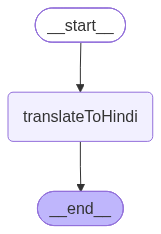

In [9]:
subGraph = StateGraph(SubState)
subGraph.add_node("translateToHindi",translateToHindi)
subGraph.add_edge(START, "translateToHindi")
subGraph.add_edge("translateToHindi", END)

SubGraph = subGraph.compile()
SubGraph

In [10]:
class ParentState(TypedDict):
  question: str
  response_eng: str
  response_hindi: str

In [12]:
def generateResponse(state: ParentState):
  prompt = f"You are a helpful assistant. Answer clearly. \n\nQuestion: {state['question']}"
  response = model.invoke(prompt).content
  return {'response_eng': response}

def translateResponse(state: ParentState):
  result = SubGraph.invoke({'input_text': state['response_eng']}) # <---------
  return {'response_hindi': result['translated_text']}

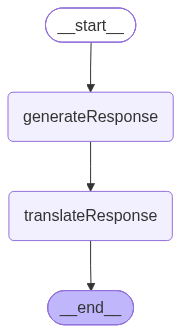

In [13]:
parent = StateGraph(ParentState)
parent.add_node("generateResponse",generateResponse)
parent.add_node("translateResponse",translateResponse)
parent.add_edge(START, "generateResponse")
parent.add_edge("generateResponse", "translateResponse")
parent.add_edge("translateResponse", END)

ParentGraph = parent.compile()
ParentGraph

In [14]:
ParentGraph.invoke({'question': "What is the capital of India?"})

{'question': 'What is the capital of India?',
 'response_eng': 'The capital of India is New Delhi.',
 'response_hindi': 'भारत का राजधानी नई दिल्ली है।'}

## Method 2 (Add a Graph as a Node -> Shared State)

In [20]:
class SharedState(TypedDict):
  question: str
  response_eng: str
  response_hindi: str

In [27]:
# Inside Graph
def translateToHindi(state: SharedState):
  prompt = f"Translate the following text to hindi, keep it natural and clear, do not add any extra content. Text: {state["question"]}".strip()
  translated_text = model.invoke(prompt).content
  return {'response_hindi': translated_text}

sub = StateGraph(SharedState)
sub.add_node("translateToHindi",translateToHindi)

sub.add_edge(START, "translateToHindi")
sub.add_edge("translateToHindi", END)

SubGraph = sub.compile()

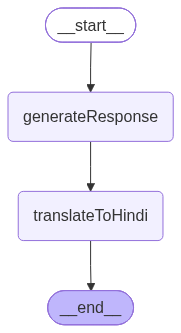

In [28]:
def generateResponse(state: SharedState):
  prompt = f"You are a helpful assistant. Answer clearly. \n\nQuestion: {state['question']}"
  response = model.invoke(prompt).content
  return {'response_eng': response}


parent = StateGraph(SharedState)
parent.add_node("generateResponse", generateResponse)
parent.add_node("translateToHindi", SubGraph) # <-----------------------------

parent.add_edge(START, "generateResponse")
parent.add_edge("generateResponse", "translateToHindi")
parent.add_edge("translateToHindi", END)

ParentGraphShared = parent.compile()
ParentGraphShared

In [29]:
ParentGraphShared.invoke({'question': "What is the capital of India?"})

{'question': 'What is the capital of India?',
 'response_eng': 'The capital of India is New Delhi.',
 'response_hindi': 'भारत के राष्ट्रीय शहर क्या है?'}